## GAN for Faces
#### Basically, we are using Deep Convolutional Generative Adversial Network (DCGAN) for the generation of the faces with light weight dataset collected from our classroom.

In [1]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid, save_image
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# Hyperparameters 
batch_size = 32
image_size = 64
latent_dim = 100
lr = 0.0002
num_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Transforms 
transform = transforms.Compose([
    transforms.Grayscale(),                      # Convert to grayscale
    transforms.Resize((64, 64)),                 # Resize           
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),          # [-1, 1]
])

In [4]:
dataset = ImageFolder(root='./dataset', transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

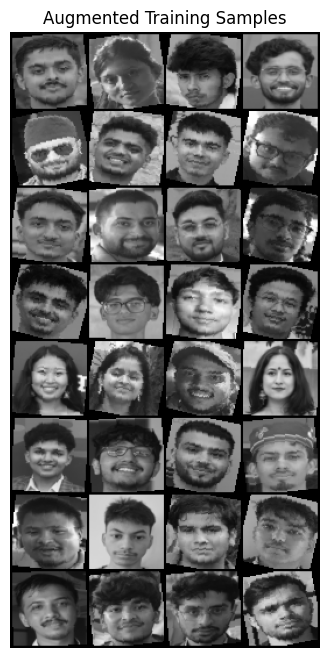

In [5]:
# Get a batch of augmented images
data_iter = iter(dataloader)
images, _ = next(data_iter)

# Make grid and display
grid_img = make_grid(images, nrow=4, normalize=True)

plt.figure(figsize=(8, 8))
plt.imshow(grid_img.permute(1, 2, 0))  # Convert from CHW to HWC
plt.title("Augmented Training Samples")
plt.axis('off')
plt.show()

In [6]:
# Generator 
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [7]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

In [8]:
# Initialize Models 
G = Generator().to(device)
D = Discriminator().to(device)

In [9]:
# Loss and Optimizers 
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [10]:
# Training 
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

In [11]:
# training loop
train_losses_D = []
train_losses_G = []

for epoch in range(num_epochs):
    loop = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch [{epoch+1}/{num_epochs}]")
    
    loss_D_epoch = 0.0
    loss_G_epoch = 0.0

    for batch_idx, (real_imgs, _) in loop:
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        ### === Train Discriminator === ###
        optimizer_D.zero_grad()

        # Real images
        real_labels = torch.ones(b_size, device=device)
        output_real = D(real_imgs).view(-1)
        loss_real = criterion(output_real, real_labels)

        # Fake images
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_imgs = G(noise)
        fake_labels = torch.zeros(b_size, device=device)
        output_fake = D(fake_imgs.detach()).view(-1)
        loss_fake = criterion(output_fake, fake_labels)

        # Total Discriminator Loss
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        ### === Train Generator === ###
        optimizer_G.zero_grad()

        fake_labels = torch.ones(b_size, device=device)  # Generator wants D to believe fakes are real
        output = D(fake_imgs).view(-1)
        loss_G = criterion(output, fake_labels)
        loss_G.backward()
        optimizer_G.step()

        # Logging
        loss_D_epoch += loss_D.item()
        loss_G_epoch += loss_G.item()

        loop.set_postfix(loss_D=loss_D.item(), loss_G=loss_G.item())

    avg_loss_D = loss_D_epoch / len(dataloader)
    avg_loss_G = loss_G_epoch / len(dataloader)

    print(f"\nEpoch {epoch+1} | Discriminator Loss: {avg_loss_D:.4f} | Generator Loss: {avg_loss_G:.4f}\n")

    train_losses_D.append(avg_loss_D)
    train_losses_G.append(avg_loss_G)

    # (Optional) Save generated images for visual tracking
    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()
        save_image(fake, f"outputs/fake_epoch_{epoch+1}.png", normalize=True)


Epoch [1/100]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [1/100]: 100%|██████████| 2/2 [00:01<00:00,  1.22it/s, loss_D=0.719, loss_G=4.53]



Epoch 1 | Discriminator Loss: 1.0168 | Generator Loss: 3.8855



Epoch [2/100]: 100%|██████████| 2/2 [00:01<00:00,  1.75it/s, loss_D=0.278, loss_G=4.98]



Epoch 2 | Discriminator Loss: 0.3337 | Generator Loss: 4.7129



...


Epoch 98 | Discriminator Loss: 0.1345 | Generator Loss: 7.7156



Epoch [99/100]: 100%|██████████| 2/2 [00:01<00:00,  1.82it/s, loss_D=0.172, loss_G=5.56]



Epoch 99 | Discriminator Loss: 0.1758 | Generator Loss: 8.7850



Epoch [100/100]: 100%|██████████| 2/2 [00:01<00:00,  1.93it/s, loss_D=4.34, loss_G=9.02]


Epoch 100 | Discriminator Loss: 2.3504 | Generator Loss: 14.4635

